# Análise Exploratória

Esse notebook faz parte do Tech Challenge da primeira fase da pós graduação de AI Scientist da FIAP. 

Esse projeto propõe que o grupo realize uma análise da base de dados de NPS de um e-commerce, buscando entender padrões que mais influenciam para tornar clientes promotores e detratores, sendo capaz de direcionar o time de negócios e tomada de decisões que buscam melhorar a experiência do cliente. 

O contexto, escopo e as métricas de avaliação desse projeto foram definidos anteriormente em outro documento. 
Em outro momento, foi realizado um Sanity Check dos dados disponibilizados.
O Sanity Check se encontra em `notebooks/sanity/Sanity Check dos dados.ipynb` dentro deste repositório. Para mais detalhe desse e mais arquivos, leia o README.md na raiz do repositório. 

O objetivo desse notebook é realizar a análise exploratória solicitada. Como suporte para a realização, foi gerado um artefato de mindmap, disponível como markdown em `docs/eda_mindmap.md`. Essa análise segue o passo a passo estabelecido nesse mindmap, que ajudará a responder as principais perguntas de negócio envolvidas.


**Fontes de dados**

- **desafio_nps_fase_1_feature_engineering.csv:** arquivo CSV com as colunas criadas no decorrer no notebook em que foram adicionadas as features, disponível em `notebooks/sanity`. 



## 0. Configurações iniciais e import de pacotes usados

In [1]:
%load_ext autoreload
%autoreload 2

In [60]:
from pathlib import Path
import sys
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
import matplotlib.pyplot as plt
import numpy as np

# Pasta raiz do repo
project_root = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / ".git").exists())
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

import src.utils.data_viz as dv
import src.utils.eda_utils as eda

## 0.1 Leitura da base

In [3]:
df = pd.read_csv(f'{project_root}/dados/processed/desafio_nps_fase_1_feature_engineering.csv')

## 1. Bloco 1:
### Logistica impacta satisfação?

- **H1:** Atraso na entrega reduz fortemente o NPS.
- **H2:** Mais tentativas de entrega reduzem NPS.
- **H3:** Tempo total de entrega importa menos que atraso percebido?
- **H4:** Frete alto tem associação com NPS.
- **H5:** Frete alto associado com atraso causa mais insatisfação que somente atraso 

### H1: Atraso na entrega reduz fortemente NPS

A primeira investigação é: Existe diferença na distribuição de NPS dos clientes que tiveram ao menos um dia de atraso em suas entregas e dos que não tiveram nenhum dia de atraso?

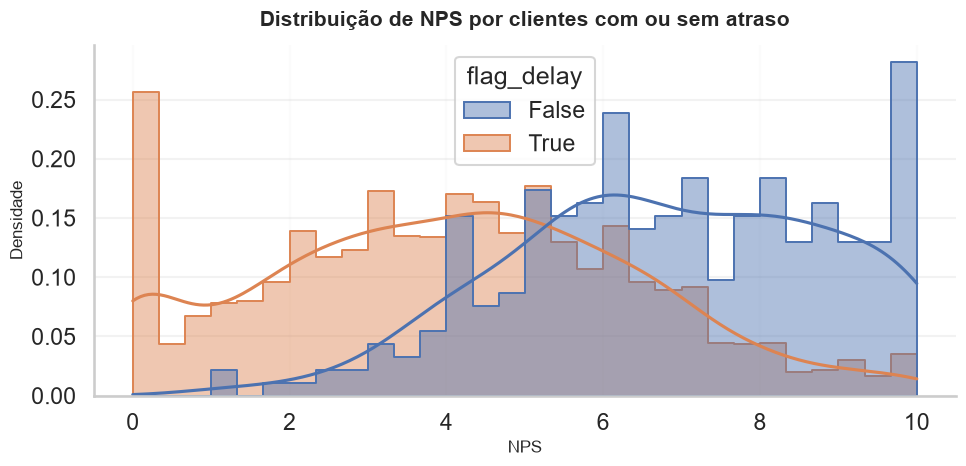

In [5]:
dv.plot_comparative_histogram(
    df,
    value_col="nps_score",
    group_col="flag_delay",
    title="Distribuição de NPS por clientes com ou sem atraso",
    x_label="NPS"
)

Os histogramas dos dois grupos mostra que claramente existe, de fato, uma diferença na distribuição entre clientes com e sem atraso.

Podemos quantificar essa diferença de forma inicial usando medidas de tendência central:

In [14]:
print("Estatísticas descritivas de NPS para grupo de clientes com atraso:")
df.loc[df["flag_delay"] == 1]['nps_score'].describe()

Estatísticas descritivas de NPS para grupo de clientes com atraso:


count    2223.000000
mean        4.069816
std         2.392110
min         0.000000
25%         2.300000
50%         4.100000
75%         5.750000
max        10.000000
Name: nps_score, dtype: float64

In [15]:
print("Estatísticas descritivas de NPS para grupo de clientes sem atraso:")
df.loc[df["flag_delay"] == 0]['nps_score'].describe()

Estatísticas descritivas de NPS para grupo de clientes sem atraso:


count    277.000000
mean       6.856679
std        2.013667
min        1.100000
25%        5.500000
50%        6.800000
75%        8.500000
max       10.000000
Name: nps_score, dtype: float64

É notável que a distribuição de clientes com atraso e sem atraso é significativamente diferente, com valores de média e mediana muito deslocados, corroborando com a hipótese de que o atraso impacta negativamente o NPS.

O grupo de clientes com pelo menos um dia de atraso tem NPS médio de 4,07, enquanto clientes sem atraso em suas entregas tem NPS médio de 6,85. 

Além disso, em ambos os grupos, a mediana se encontra próxima à média, indicando que a média parece ser uma medida representativa da tendência central e que os resultados não aparentam estar fortemente distorcidos por valores extremos

Em seguida, precisamos responder uma pergunta importante para continuar investigando a hipótese:

Existe uma "tolerância" a dias de atraso? Ou o NPS tende a cair de forma linear conforme aumentam os dias de atraso?

Pra isso, podemos usar um gráfico de dispersão com as variáveis de NPS e dias de atraso

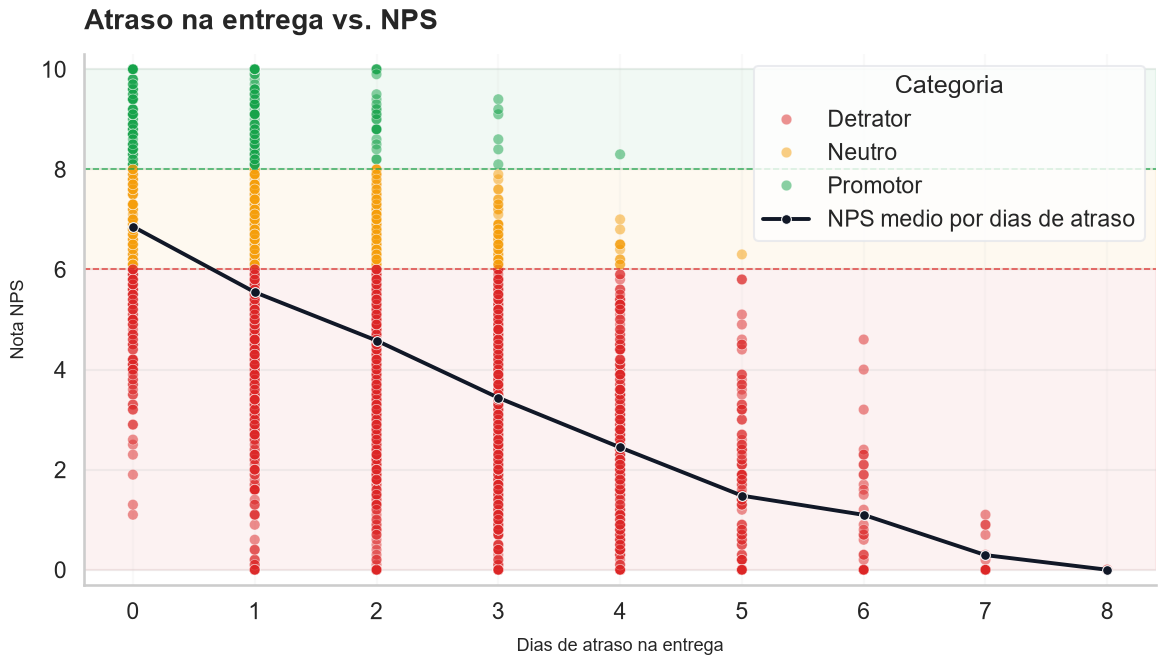

In [4]:
fig, ax = dv.plot_nps_relationship(
    df,
    x_col="delivery_delay_days",
    title="Atraso na entrega vs. NPS",
    x_label="Dias de atraso na entrega",
    mean_line_label="NPS medio por dias de atraso",
)

Em primeira análise, parece haver uma relação linear negativa entre a quantidade de dias de atraso e o NPS. Essa relação linear, inclusive, parece indicar que não existe um limiar de "tolerância" para atraso, a partir do qual o atraso passa a influenciar MAIS no NPS.

Para verificar essa relação, podemos, além das visualizações geradas anteriormente, calcular a correlação entre dias de atraso e score de NPS. Como verificamos no gráfico de dispersão acima que a relação parece se comportar de forma linear, podemos usar o coeficiente de correlação de Pearson, que tem como premissas: 

- Relação linear entre as variáveis
- Variáveis numéricas
- Não haver predominância de outliers na distribuição das variáveis e em suas medidas de tendência central
- Observações independentes

In [8]:
df[["nps_score", "delivery_delay_days"]].corr(method = 'pearson')

,nps_score,delivery_delay_days
nps_score,1.00000,-0.59726
delivery_delay_days,-0.59726,1.00000


Mais uma vez, por meio do cálculo do coeficiente de correlação, fica claro há evidências de associação entre a quantidade de dias de atraso e o score de NPS, uma vez que a correlação de -0,6 obtida é considerada uma correlação moderada de magnitude relevante, de acordo com o artigo _Correlation Coefficients: Appropriate Use and Interpretation_ de Schober, et. al (2018)

Como um aprofundamento dessa hipótese, podemos tentar entender como é a variação média esperada de NPS associada a cada dia adicional de atraso, usando um modelo simples de regressão. No entanto, o uso desse modelo não deve ser interpretado como efeito causal isolado, já que outras variáveis potencialmente relacionadas à satisfação não foram controladas. Usando um modelo de regressão múltipla, poderíamos, por exemplo, entender como é essa relação se mantivessemos todas as outras variáveis constantes, e, com o auxílio de outras análises, estabelecer uma relação causal mais clara. Esse modelo mais complexo, no entanto, não será abordado durante a presente análise, que tem fins exploratórios. 


In [9]:
# Variáveis da regressão
x_col = "delivery_delay_days"
y_col = "nps_score"

# dataframe só com as colunas necessárias
model_df = df[[x_col, y_col]].dropna().copy()

X = sm.add_constant(model_df[x_col])
y = model_df[y_col]

# Fit de modelo de regressão linear simples de uma variável
model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              nps_score   R-squared:                       0.357
Model:                            OLS   Adj. R-squared:                  0.356
Method:                 Least Squares   F-statistic:                     1385.
Date:                Mon, 22 Jun 2026   Prob (F-statistic):          1.31e-241
Time:                        14:58:15   Log-Likelihood:                -5296.3
No. Observations:                2500   AIC:                         1.060e+04
Df Residuals:                    2498   BIC:                         1.061e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   6.6332    

In [10]:
intercept = model.params["const"]
coef = model.params[x_col]
r2 = model.rsquared
p_value = model.pvalues[x_col]
conf_int = model.conf_int().loc[x_col]

print(f"Intercepto: {intercept:.3f}")
print(f"Coeficiente de dias de atraso: {coef:.3f}")
print(f"R²: {r2:.3f}")
print(f"p-valor: {p_value:.4f}")
print(f"IC 95% do coeficiente: [{conf_int[0]:.3f}, {conf_int[1]:.3f}]")

Intercepto: 6.633
Coeficiente de delivery_delay_days: -1.031
R²: 0.357
p-valor: 0.0000
IC 95% do coeficiente: [-1.085, -0.977]


Na amostra analisada, o modelo de regressão linear simples indica que cada dia adicional de atraso está associado, em média, a uma redução de 1,03 ponto no score de NPS.

#### Conclusões da hipótese: 

Clientes com ao menos um dia de atraso apresentam em média, um NPS 2.8 pontos menor do que clientes em que não tiveram nenhum dia de atraso.

Além disso, podemos dizer que há associação linear entre as variáveis, corroborada por meio do modelo simples de regressão, bem como do cálculo do coeficiente de correlação entre as variávies de NPS e dias de atraso e da relação visual entre ambas. 

Embora não possamos destacar causalidade direta entre as variáveis a partir dessas análises, podemos concluir que há evidências que apontam que associação negativa entre dias de atraso e NPS, e portanto sustentar a hipótese, sob essas condições. 

### **H2:** Mais tentativas de entrega reduzem NPS.

De forma análoga ao que foi feito em H1, podemos estudar a relação entre as variáveis de quantidade de tentativas de entregas e score NPS, como uma primeira busca por respostas para essa hipótese.

No Sanity Check foi observado que só existem 3 valores distintos para a variável de tentativas de entregas (`delivery_attempts`). Dessa forma, uma visualização de boxplot pode ser mais adequada para identificar essa relação do que um gráfico de dispersão. 

Também podemos verificar as medidas de tendência central.

<string>:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



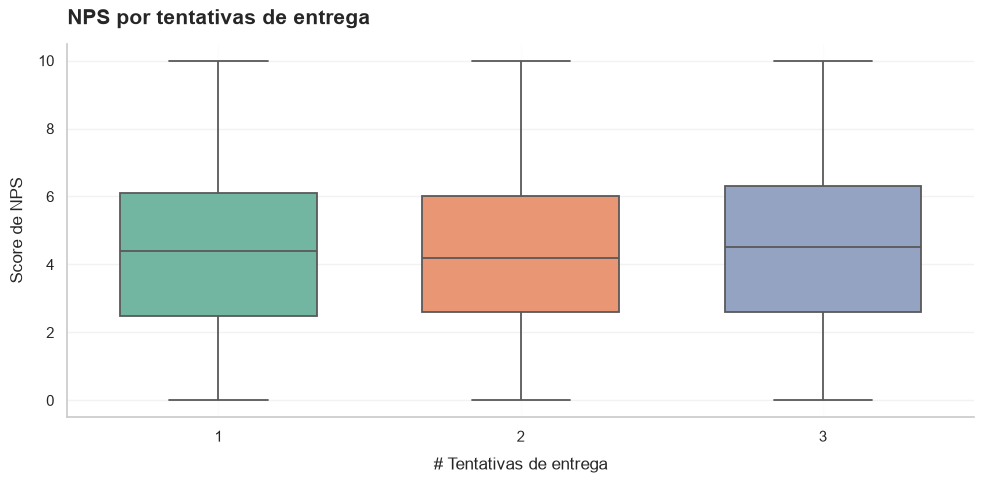

In [24]:
fig, ax = dv.plot_boxplot(
    df,
    x_col="delivery_attempts",
    y_col="nps_score",
    hue_col=None,
    title="NPS por tentativas de entrega",
    x_label="# Tentativas de entrega",
    y_label="Score de NPS",
    legend_title="Categoria NPS",
)

In [25]:
summary = (
    df
    .groupby(["delivery_attempts"])["nps_score"]
    .agg(
        quantidade="count",
        media="mean",
        mediana="median"
    )
    .round(2)
    .reset_index()
)

summary

,delivery_attempts,quantidade,media,mediana
0,1,824,4.35,4.4
1,2,838,4.26,4.2
2,3,838,4.52,4.5


Tanto pelo boxplot quanto pelas estatísticas descritivas dos grupos, não parece haver diferença entre eles que indique associação entre a variável de tentativas de entrega e NPS.

Como aprofundamento dessa hipótese, podemos verificar, por exemplo se não há associação entre dias de atraso e quantidade de tentativas de entrega, o que é esperado pelo resultado parcial dessa hipótese e pelo resultado de H1. 

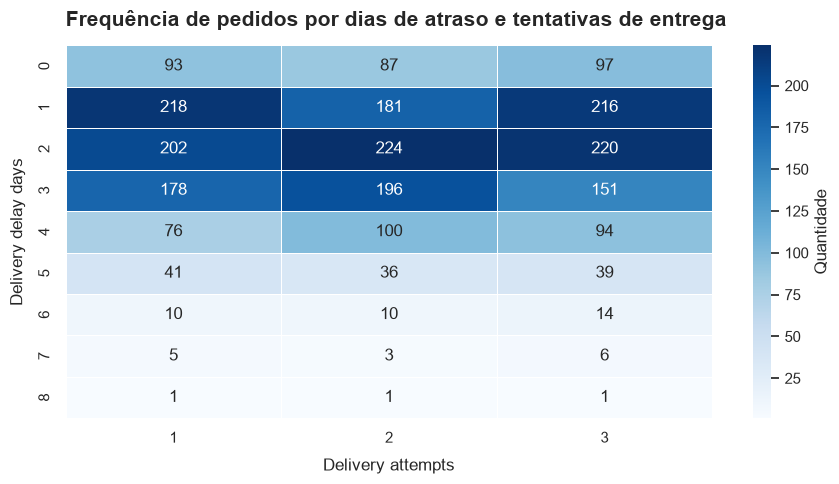

In [34]:
fig, ax = dv.plot_crosstab_heatmap(
    df,
    row_col="delivery_delay_days",
    col_col="delivery_attempts",
    normalize=None,
    title="Frequência de pedidos por dias de atraso e tentativas de entrega",
)

O comportamento mostrou-se conforme o esperado, pelo gráfico acima

#### Conclusões da hipótese:

Não temos evidência suficiente para afirmar que existe associação entre Quantidade de tentativas de entrega e Score de NPS

### **H3:** Tempo total de entrega importa menos que atraso percebido?

Inicialmente, podemos fazer uma verificação do gráfico de dispersão entre as variáveis envolvidas.

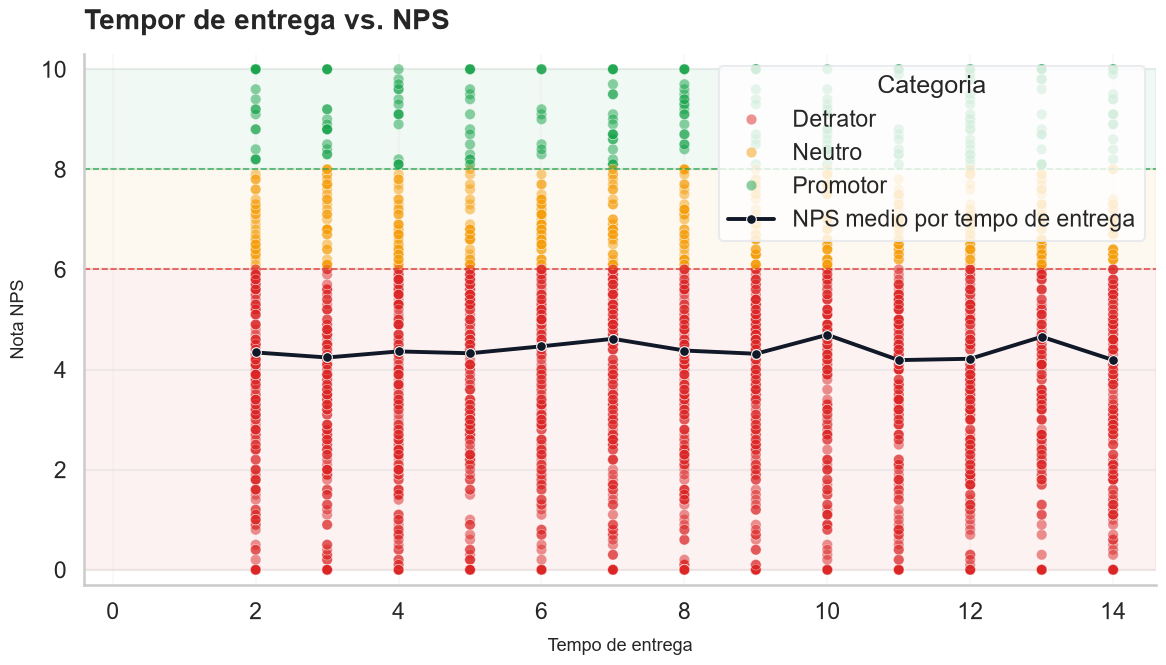

In [36]:
fg, ax = dv.plot_nps_relationship(
    df,
    x_col="delivery_time_days",
    title="Tempor de entrega vs. NPS",
    x_label="Tempo de entrega",
    mean_line_label="NPS medio por tempo de entrega",
)


#### Conclusão da hipótese: 
Apenas por observação do gráfico de dispersão, por observar que não há associação entre tempo de entrega e NPS, e tendo em vista o que foi observado em H1, podemos sustentar a hipótese de que de fato, o tempo total de entrega impacta menos que o atraso percebido na satsifação, tendo o NPS como variável de análise. 

### **H4:** Fretes altos tem associação com NPS

Para uma primeira análise direta dessa hipótese, podemos novamente usar o gráfico de dispersão.

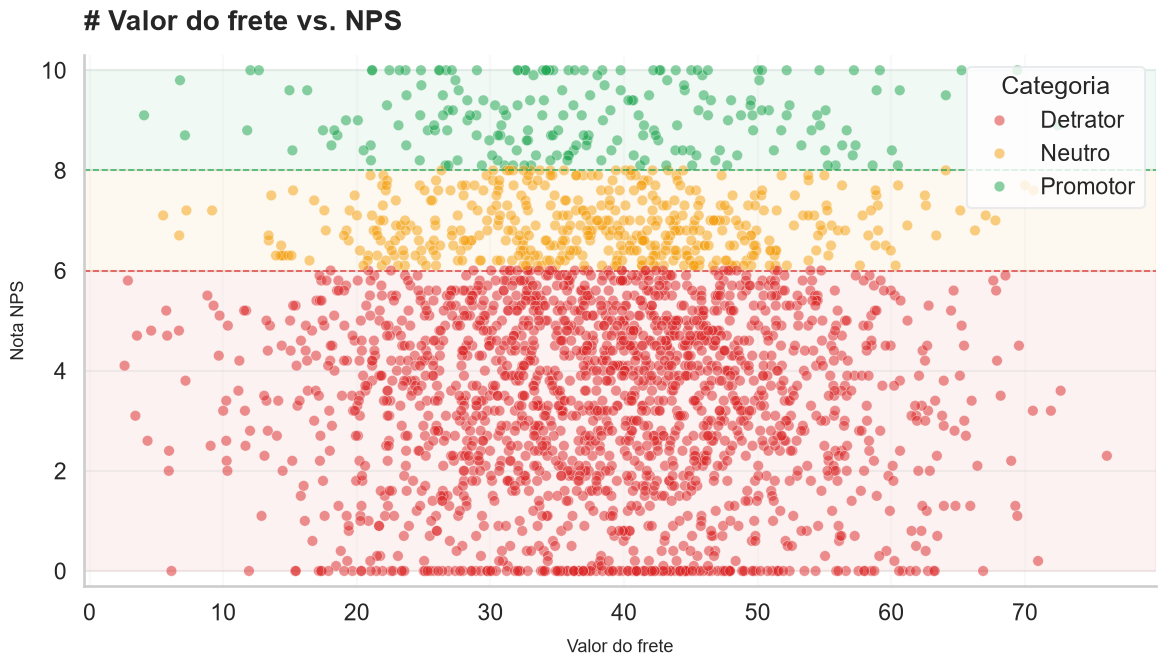

In [43]:
fig, ax = dv.plot_nps_relationship(
    df,
    x_col="freight_value",
    title="# Valor do frete vs. NPS",
    x_label="Valor do frete",
    show_mean_line=False
)

A primeira vista, utilizando o valor absoluto do frete, não parece haver associação entre as variáveis.

Porém, existem alguns aprofundamentos que podem ser feitos para explorar essa hipótese. 

Um exemplo é fazer uma verificação usando o valor do frete de forma relativa ao valor da compra. Essa feature foi criada na etapa de feature engineering, e está armazenada na coluna `freight_rate`

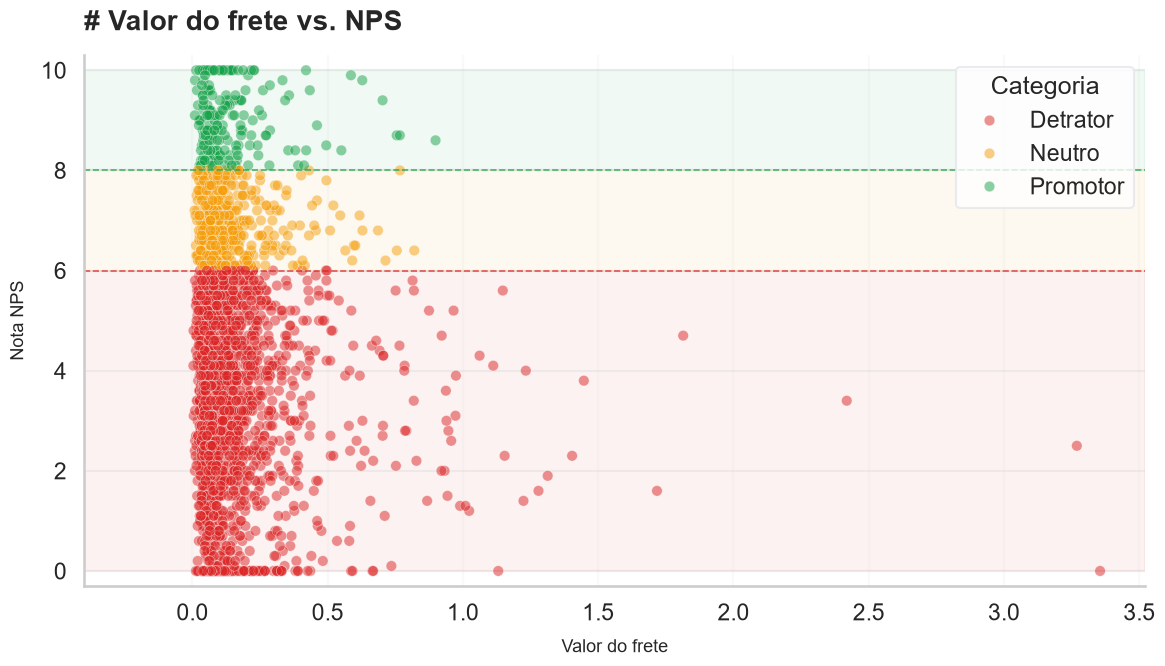

In [45]:
fig, ax = dv.plot_nps_relationship(
    df,
    x_col="freight_rate",
    title="# Valor do frete vs. NPS",
    x_label="Valor do frete",
    show_mean_line=False
)

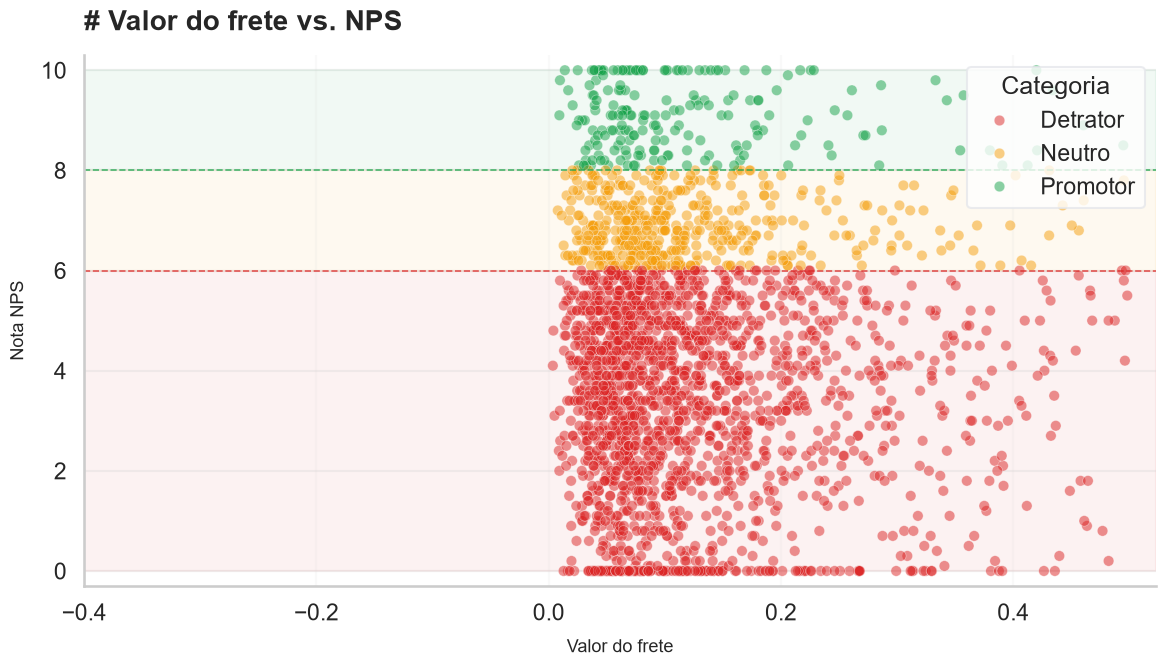

In [46]:
# Verificação em faixa mais comum de valores
fig, ax = dv.plot_nps_relationship(
    df.loc[df["freight_rate"] < 0.5],
    x_col="freight_rate",
    title="# Valor do frete vs. NPS",
    x_label="Valor do frete",
    show_mean_line=False
)

Ainda assim, visualizando de forma relativa, não há evidências para sustentar que existe associação entre o valor do frete e a variável de satisfação analisada

Outro aprofundamento válido é pensar em fazer recortes para entender como o frete combinado com outras variáveis de perfil como faixa etária ou região podem impactar mais no NPS. 

Esses recortes não são obrigatórios para validar a hipótese inicial, mas podem ajudar a entender comportamentos diferentes entre grupos de clientes, considerando a variável do frete.

Como forma de aprofundamento, utilizaram-se 2 variáveis para fazer esse recorte:

- Região do cliente: A depender do negócio, regiões diferentes podem ter variações maiores ou menores de frete, e, clientes dentro de uma região podem ter comportamentos diferentes e percepções de insatisfação diferentes considerando o valor do frete. 
- Faixa etária: Em alguma faixa etária, os clientes podem estar mais suscetíveis a associar fretes caros com insatisfação.

H4.1: Frete x Região x NPS

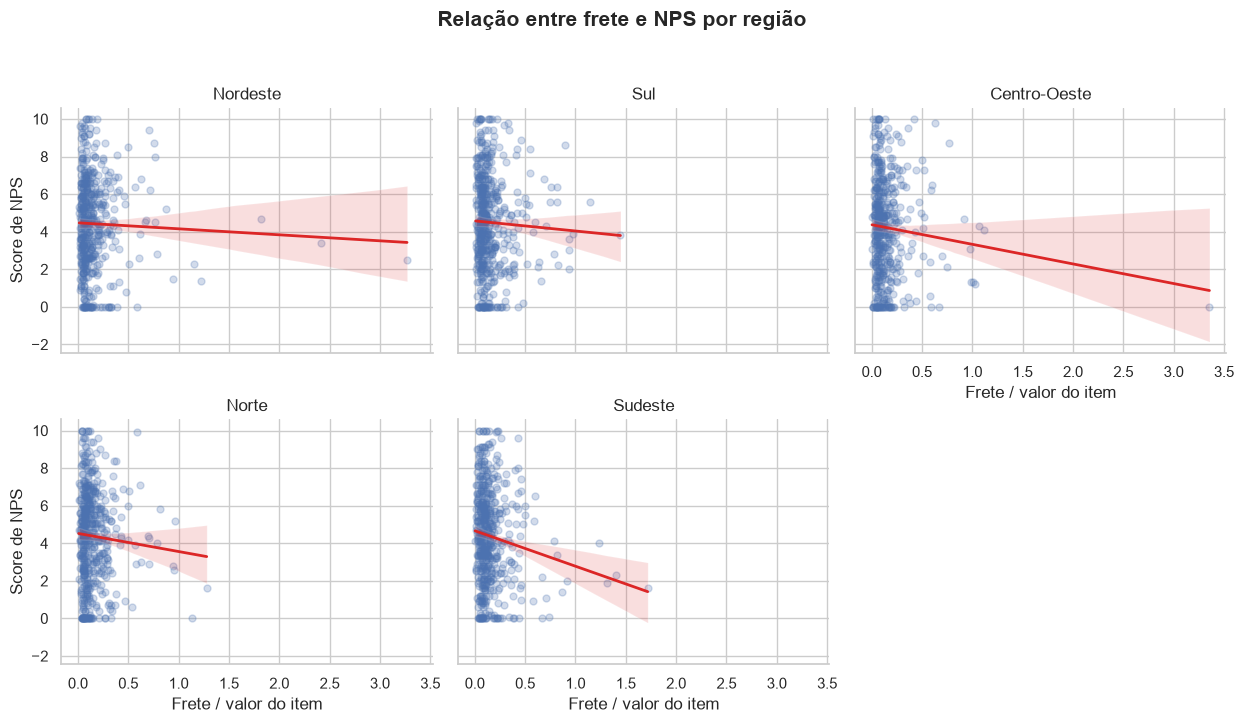

In [55]:
g = dv.plot_faceted_regression(
    df,
    x_col="freight_rate",
    y_col="nps_score",
    facet_col="customer_region",
    title="Relação entre frete e NPS por região",
    x_label="Frete / valor do item",
    y_label="Score de NPS",
)

H4.2. Frete x Faixa Etária x NPS

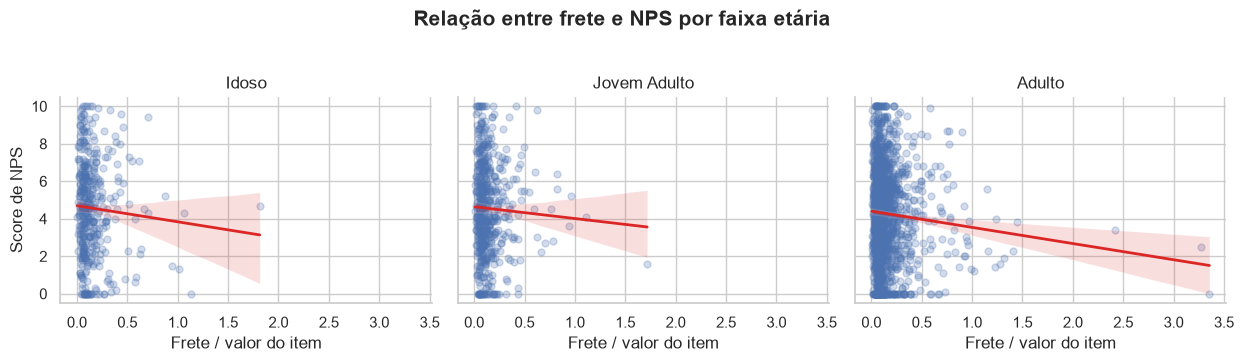

In [57]:
g = dv.plot_faceted_regression(
    df,
    x_col="freight_rate",
    y_col="nps_score",
    facet_col="faixa_etaria",
    title="Relação entre frete e NPS por faixa etária",
    x_label="Frete / valor do item",
    y_label="Score de NPS",
)

Considerando o comportamento observado, não parece haver associação entre NPS e valor do frente em nenhum dos recortes feitos. Os coeficientes das regressões realizados acima são muito influenciados por poucos pontos dispersos e que não devem ser considerados para tirar conclusões, e na faixa em que a maior parte dos valores de taxa de frete estão concentrados, não parece haver associação com NPS.

#### Conclusão da hipótese: 

Não há evidência para sustentar a hipótese de que fretes altos tem associação com NPS

### **H5:** Frete alto + atraso impacta mais no NPS do que somente atraso. 

Essa hipótese pode ser analisada de diferentes formas

Uma forma é considerar, por exemplo, o grupo dos clientes que sofreram com atraso e entender se há diferença entre o NPS daqueles que foram cobrados fretes maiores.

In [62]:
delay_df = df.loc[df["flag_delay"] == 1].copy()

freight_q3 = delay_df["freight_rate"].quantile(0.75)

delay_df["grupo_frete"] = np.where(
    delay_df["freight_rate"] >= freight_q3,
    "Frete alto (>= Q3)",
    "Demais clientes com atraso"
)

print(f"3º quartil de freight_rate entre clientes com atraso: {freight_q3:.4f}")

# Comparação entre grupos exclusivos: frete alto vs demais clientes com atraso
comparacao_grupos = eda.compare_groups(
    delay_df,
    group_col="grupo_frete",
    value_col="nps_score"
)

comparacao_grupos

3º quartil de freight_rate entre clientes com atraso: 0.1740


,grupo_frete,count,mean,median,std,min,q1,q3,max
0,Demais clientes com atraso,1667,4.16,4.2,2.40,0.0,2.4,5.8,10.0
1,Frete alto (>= Q3),556,3.81,3.9,2.35,0.0,2.1,5.5,10.0
